In [ ]:
import torch

print(f"torch version: {torch.__version__}")
print(f"torch cuda version: {torch.version.cuda}")
device = torch.device(torch.cuda.current_device() if torch.cuda.is_available() else "cpu")
print(f"torch device: {device}")
print(f"device name: {torch.cuda.get_device_name(device) if torch.cuda.is_available() else 'cpu'}")

torch version: 2.6.0+cu126
torch cuda version: 12.6
torch device: cuda:0
device name: NVIDIA GeForce RTX 4090 Laptop GPU


In [ ]:
import os

from common import SAVE_MODEL_PATH
from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj"],
)

model_id = "mistralai/Mistral-7B-Instruct-v0.3"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

MISC_DATA_PATH: ..\..\MISC
JOB_DATA_PATH: ..\..\MISC\job_data_files


2025-04-28 01:31:10 - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
import tqdm
from mistral_data import MissionType, MistralData


def find_wa_answer(text: str) -> str:
    text = text.replace("\n", " ").replace("'", "").split(" ")
    for i in range(len(text), 0, -1):
        if text[i - 1] in ["OnSite", "Remote", "Hybrid"]:
            return text[i - 1]
    return "None"


def predict(Model, Tokenizer, MistralData: MistralData) -> list:
    y_pred = []
    test_data = MistralData.test_dataset["train"]
    for i in tqdm.tqdm(range(len(test_data))):
        input_text = test_data["input"][i]
        instruction_text = test_data["instruction"][i]
        format_input = f"<s>[INST] {instruction_text} {input_text} [/INST]"
        input_ids = Tokenizer(format_input, return_tensors="pt").input_ids.to(device)
        attention_mask = Tokenizer(format_input, return_tensors="pt").attention_mask.to(
            device
        )
        Model.gradient_checkpointing_enable()
        Model.generation_config.pad_token_id = Tokenizer.pad_token_id
        output = Model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            num_return_sequences=1,
        )
        Model.gradient_checkpointing_enable()
        # print(sequences[0]["generated_text"])
        output_text = Tokenizer.decode(output[0], skip_special_tokens=True)
        # print(f"Output: {output_text}")
        a = find_wa_answer(output_text)
        # print(f"Answer: {a}")
        y_pred.append(a)
    return y_pred


y_pred = predict(model, tokenizer, MistralData(MissionType.WA))
y_test = MistralData(MissionType.WA).df_test["y_true"].tolist()

print(f"y_test: {y_test}")
print(f"y_pred: {y_pred}")

2025-04-28 01:24:01 - INFO - Creating jsonl for Index(['id', 'job_ad', 'y_true'], dtype='object') rows
Creating jsonl: 100%|██████████| 99/99 [00:00<00:00, 49509.49it/s]


Generating train split: 0 examples [00:00, ? examples/s]

2025-04-28 01:24:02 - INFO - Creating jsonl for Index(['id', 'job_ad', 'y_true'], dtype='object') rows
Creating jsonl: 100%|██████████| 99/99 [00:00<00:00, 65691.52it/s]


Generating train split: 0 examples [00:00, ? examples/s]

100%|██████████| 99/99 [01:33<00:00,  1.06it/s]
2025-04-28 01:25:35 - INFO - Creating jsonl for Index(['id', 'job_ad', 'y_true'], dtype='object') rows
Creating jsonl: 100%|██████████| 99/99 [00:00<00:00, 33234.84it/s]


Generating train split: 0 examples [00:00, ? examples/s]

2025-04-28 01:25:36 - INFO - Creating jsonl for Index(['id', 'job_ad', 'y_true'], dtype='object') rows
Creating jsonl: 100%|██████████| 99/99 [00:00<00:00, 65837.34it/s]


Generating train split: 0 examples [00:00, ? examples/s]

y_test: ['OnSite', 'OnSite', 'Remote', 'Hybrid', 'Remote', 'OnSite', 'Hybrid', 'Remote', 'Hybrid', 'Remote', 'Hybrid', 'OnSite', 'Remote', 'OnSite', 'OnSite', 'OnSite', 'OnSite', 'Remote', 'OnSite', 'Remote', 'Remote', 'Hybrid', 'Remote', 'Hybrid', 'OnSite', 'OnSite', 'Hybrid', 'OnSite', 'Remote', 'OnSite', 'OnSite', 'Hybrid', 'Hybrid', 'Remote', 'OnSite', 'OnSite', 'OnSite', 'Hybrid', 'Hybrid', 'OnSite', 'Hybrid', 'Remote', 'Remote', 'Remote', 'Hybrid', 'OnSite', 'OnSite', 'Remote', 'Remote', 'OnSite', 'Hybrid', 'Hybrid', 'OnSite', 'OnSite', 'OnSite', 'Remote', 'OnSite', 'Hybrid', 'Hybrid', 'Remote', 'OnSite', 'Hybrid', 'OnSite', 'Hybrid', 'Remote', 'Remote', 'Remote', 'Hybrid', 'OnSite', 'OnSite', 'Hybrid', 'OnSite', 'OnSite', 'Hybrid', 'OnSite', 'Remote', 'OnSite', 'Remote', 'OnSite', 'OnSite', 'Hybrid', 'OnSite', 'Hybrid', 'OnSite', 'Remote', 'Hybrid', 'OnSite', 'OnSite', 'OnSite', 'Hybrid', 'Remote', 'OnSite', 'OnSite', 'Remote', 'OnSite', 'Hybrid', 'OnSite', 'OnSite', 'OnSite']
y

Accuracy: 	 0.52525253
Precision: 	 0.92207792
Recall: 	 0.52525253
F1 Score: 	 0.65697005
Classification Report: 
              precision    recall  f1-score   support

      Hybrid       0.71      0.56      0.62        27
        None       0.00      0.00      0.00         0
      OnSite       1.00      0.41      0.58        46
      Remote       1.00      0.69      0.82        26

    accuracy                           0.53        99
   macro avg       0.68      0.42      0.51        99
weighted avg       0.92      0.53      0.66        99

Labels: ['Hybrid', 'Remote', 'None', 'OnSite']


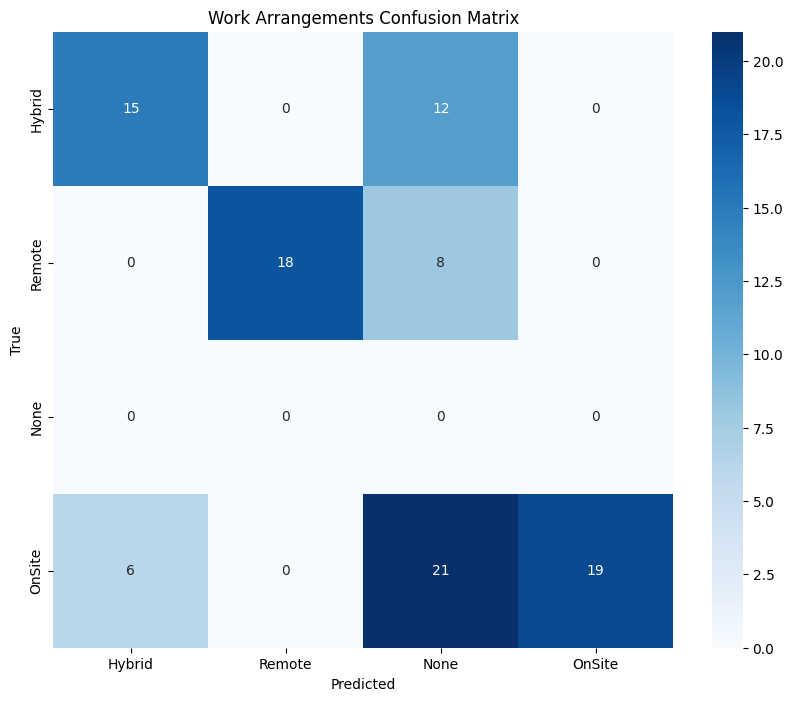

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: \t {accuracy:.8f}")
# Calculate precision

precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
print(f"Precision: \t {precision:.8f}")

# Calculate recall
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Recall: \t {recall:.8f}")

# Calculate F1 score
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
print(f"F1 Score: \t {f1:.8f}")

# # Generate classification report
report = classification_report(y_test, y_pred, zero_division=0)
print(f"Classification Report: \n{report}")

import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
from sklearn.metrics import confusion_matrix

# labels = distinct(y_test + y_pred)
labels = list(set(y_test + y_pred))
print(f"Labels: {labels}")
confusion = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Work Arrangements Confusion Matrix")
plt.show()

For other tasks, it is difficult to judge the performance because the model without fine-tuning does not produce well structured results

In [7]:
import tqdm
from mistral_data import MissionType, MistralData


def predict_sa(Model, Tokenizer, MistralData: MistralData) -> list:
    y_pred = []
    test_data = MistralData.test_dataset["train"]
    for i in tqdm.tqdm(range(0, 1)):
        input_text = test_data["input"][i]
        instruction_text = test_data["instruction"][i]
        format_input = f"<s>[INST] {instruction_text} {input_text} [/INST]"
        input_ids = Tokenizer(format_input, return_tensors="pt").input_ids.to(device)
        attention_mask = Tokenizer(format_input, return_tensors="pt").attention_mask.to(
            device
        )
        Model.gradient_checkpointing_enable()
        Model.generation_config.pad_token_id = Tokenizer.pad_token_id
        output = Model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            num_return_sequences=1,
            max_length=Model.config.max_position_embeddings,
        )
        Model.gradient_checkpointing_enable()
        # print(sequences[0]["generated_text"])
        output_text = Tokenizer.decode(output[0], skip_special_tokens=True)
        print(f"Output: {output_text}")
        # a = find_wa_answer(output_text)
        # print(f"Answer: {a}")
        # y_pred.append(a)
    return y_pred


y_pred = predict_sa(model, tokenizer, MistralData(MissionType.SA))
y_test = MistralData(MissionType.SA).df_test["y_true"].tolist()

print(f"y_test: {y_test}")
print(f"y_pred: {y_pred}")

2025-04-28 01:32:49 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_ad_details', 'nation_short_desc',
       'salary_additional_text', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 2267/2267 [00:00<00:00, 54176.02it/s]


Generating train split: 0 examples [00:00, ? examples/s]

2025-04-28 01:32:50 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_ad_details', 'nation_short_desc',
       'salary_additional_text', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 567/567 [00:00<00:00, 56625.80it/s]


Generating train split: 0 examples [00:00, ? examples/s]

100%|██████████| 1/1 [00:02<00:00,  2.75s/it]
2025-04-28 01:32:53 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_ad_details', 'nation_short_desc',
       'salary_additional_text', 'y_true'],
      dtype='object') rows


...

Creating jsonl: 100%|██████████| 2267/2267 [00:00<00:00, 53893.52it/s]


Generating train split: 0 examples [00:00, ? examples/s]

2025-04-28 01:32:54 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_ad_details', 'nation_short_desc',
       'salary_additional_text', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 567/567 [00:00<00:00, 46018.12it/s]


Generating train split: 0 examples [00:00, ? examples/s]

y_test: ['1500-1800-MYR-MONTHLY', '60-60-HKD-HOURLY', '0-0-None-None', '0-0-None-None', '0-0-None-None', '21-21-NZD-HOURLY', '0-0-None-None', '0-0-None-None', '32-32-AUD-HOURLY', '2000-3000-MYR-MONTHLY', '3000-4000-MYR-MONTHLY', '0-0-None-None', '0-0-None-None', '80-90-HKD-HOURLY', '142642-156491-AUD-ANNUAL', '0-0-None-None', '29-29-AUD-HOURLY', '1500-2500-MYR-MONTHLY', '66028-68086-AUD-ANNUAL', '0-0-None-None', '3000-4000-SGD-MONTHLY', '0-0-None-None', '0-0-None-None', '73-85-HKD-HOURLY', '5000-8000-MYR-MONTHLY', '30-30-NZD-HOURLY', '0-0-None-None', '500-1250-SGD-WEEKLY', '1500-1500-MYR-MONTHLY', '750-1125-SGD-WEEKLY', '0-0-None-None', '0-0-None-None', '0-0-None-None', '1500-1500-MYR-MONTHLY', '2000-2500-SGD-MONTHLY', '58008-58008-AUD-ANNUAL', '23-29-NZD-HOURLY', '3000-6000-MYR-MONTHLY', '31-31-NZD-HOURLY', '100-100-HKD-HOURLY', '500-667-PHP-DAILY', '107-150-SGD-DAILY', '1500-1500-MYR-MONTHLY', '20-25-AUD-HOURLY', '0-0-None-None', '0-0-None-None', '2700-3000-SGD-MONTHLY', '0-0-None-No